# Perbandingan Rasio Split — Model FULL (URL + HTML, XGBoost)

Notebook ringkas yang hanya berisi pembentukan model dan perbandingan kinerjanya pada tiga rasio pembagian data: 70:30, 80:20, dan 90:10. Untuk setiap rasio, model dilatih ulang melalui alur YANG SAMA dengan skripsi_final.ipynb (split per-domain, RFECV, tuning, early stopping, threshold balanced accuracy) lalu dievaluasi (Accuracy, Precision, Recall, F1) beserta confusion matrix. Fitur yang digunakan adalah gabungan fitur leksikal URL dan fitur konten HTML stabil. Notebook ini TIDAK meng-export .pkl.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.feature_selection import RFECV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, make_scorer, balanced_accuracy_score)
from url_features import extract_url_features, extract_registered_domain, FEATURE_ORDER as URL_FEATURES

RANDOM_STATE = 42
f1_phish = make_scorer(f1_score, pos_label=0)
print('Setup OK. Fitur URL:', len(URL_FEATURES))

Setup OK. Fitur URL: 41


In [2]:
# LOAD + BERSIHKAN + BANGUN FITUR (FULL = URL + HTML stabil)
df = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')
df = df.dropna(subset=['label']).drop_duplicates(subset=['URL']).reset_index(drop=True)

# buang fitur penyebab data leakage
LEAKAGE_COLS = ['URLSimilarityIndex', 'TLDLegitimateProb', 'URLCharProb']
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns])

# label + grup domain (untuk split per-domain)
y = df['label'].astype(int).values
groups = df['URL'].apply(extract_registered_domain).values

# (a) fitur URL = 41 fitur leksikal (dihitung dari string URL via url_features.py)
X_url = pd.DataFrame(df['URL'].apply(extract_url_features).tolist(), columns=URL_FEATURES)

# (b) fitur HTML = kolom konten dataset yang stabil saja
HTML_STABLE = ['HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon',
               'Robots', 'IsResponsive', 'HasDescription', 'NoOfiFrame',
               'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
               'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
               'HasCopyrightInfo']
html_cols = [c for c in HTML_STABLE if c in df.columns]
X_html = df[html_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# (c) fitur gabungan FULL = URL + HTML
X = pd.concat([X_url, X_html], axis=1)
print('X:', X.shape, '| phishing(0)=', int((y==0).sum()), '| legit(1)=', int((y==1).sum()))
print('Fitur HTML dipakai (', len(html_cols), '):', html_cols)

X: (235370, 58) | phishing(0)= 100520 | legit(1)= 134850
Fitur HTML dipakai ( 17 ): ['HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'HasDescription', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo']


In [3]:
# PIPELINE PER RASIO (sesuai skripsi_final.ipynb): split per-domain -> RFECV -> tuning
#                 -> train + early stopping -> threshold balanced accuracy -> evaluasi
def pipeline_rasio(X, y, groups, test_size, nama):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=RANDOM_STATE)
    tr, te = next(gss.split(X, y, groups=groups))
    Xtr_all, Xte_all = X.iloc[tr].reset_index(drop=True), X.iloc[te].reset_index(drop=True)
    ytr, yte = y[tr], y[te]
    gtr = groups[tr]
    assert len(set(gtr) & set(groups[te])) == 0, 'Domain bocor!'
    spw = 1.0

    rng = np.random.RandomState(RANDOM_STATE)
    si = rng.choice(len(Xtr_all), size=min(50000, len(Xtr_all)), replace=False)

    # (1) Seleksi fitur RFECV (data latih saja)
    est = xgb.XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, subsample=0.8,
                            colsample_bytree=0.8, tree_method='hist', eval_metric='logloss',
                            random_state=RANDOM_STATE, n_jobs=-1)
    cv_sel = list(GroupKFold(n_splits=3).split(Xtr_all.iloc[si], ytr[si], groups=gtr[si]))
    rfecv = RFECV(est, step=1, min_features_to_select=8, cv=cv_sel, scoring=f1_phish, n_jobs=-1)
    rfecv.fit(Xtr_all.iloc[si], ytr[si])
    fitur = [f for f, k in zip(X.columns, rfecv.support_) if k]
    Xtr, Xte = Xtr_all[fitur], Xte_all[fitur]

    # (2) Tuning hyperparameter (RandomizedSearchCV + GroupKFold)
    ti = rng.choice(len(Xtr), size=min(60000, len(Xtr)), replace=False)
    param = {'n_estimators': [300, 400, 500, 600], 'learning_rate': [0.03, 0.05, 0.08, 0.1],
             'max_depth': [4, 5, 6, 7, 8], 'min_child_weight': [1, 3, 5, 7],
             'subsample': [0.7, 0.8, 0.9, 1.0], 'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
             'gamma': [0, 0.1, 0.2, 0.3], 'reg_alpha': [0, 0.1, 0.5, 1.0], 'reg_lambda': [1.0, 2.0, 3.0]}
    srch = RandomizedSearchCV(
        xgb.XGBClassifier(eval_metric='logloss', tree_method='hist', scale_pos_weight=spw,
                          random_state=RANDOM_STATE, n_jobs=1),
        param, n_iter=20, scoring=f1_phish,
        cv=list(GroupKFold(n_splits=3).split(Xtr.iloc[ti], ytr[ti], groups=gtr[ti])),
        n_jobs=-1, random_state=RANDOM_STATE)
    srch.fit(Xtr.iloc[ti], ytr[ti])
    bp = srch.best_params_

    # (3) Train final + early stopping (validasi per-domain)
    gv = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
    ai, vi = next(gv.split(Xtr, ytr, groups=gtr))
    fp = dict(n_estimators=1000, learning_rate=0.05, max_depth=6, min_child_weight=5,
              subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=2.0, gamma=0.1)
    fp.update(bp); fp['n_estimators'] = max(fp.get('n_estimators', 600), 1000)
    model = xgb.XGBClassifier(**fp, scale_pos_weight=spw, eval_metric='logloss',
                              early_stopping_rounds=50, tree_method='hist',
                              random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(Xtr.iloc[ai], ytr[ai], eval_set=[(Xtr.iloc[vi], ytr[vi])], verbose=False)

    # (4) Threshold via balanced accuracy (di data validasi)
    vp = model.predict_proba(Xtr.iloc[vi])[:, 0]
    cand = np.linspace(0.2, 0.8, 61)
    thr = float(cand[int(np.argmax([balanced_accuracy_score(ytr[vi], np.where(vp >= t, 0, 1)) for t in cand]))])

    # (5) Evaluasi di data uji
    pph = model.predict_proba(Xte)[:, 0]
    yp = np.where(pph >= thr, 0, 1)
    return {'rasio': nama, 'n_fitur': len(fitur), 'thr': round(thr, 3),
            'acc': accuracy_score(yte, yp), 'precision': precision_score(yte, yp, pos_label=0),
            'recall': recall_score(yte, yp, pos_label=0), 'f1': f1_score(yte, yp, pos_label=0),
            'cm': confusion_matrix(yte, yp, labels=[0, 1])}

print('Fungsi pipeline_rasio siap.')

Fungsi pipeline_rasio siap.


=== Memproses rasio 70:30 ===
=== Memproses rasio 80:20 ===
=== Memproses rasio 90:10 ===


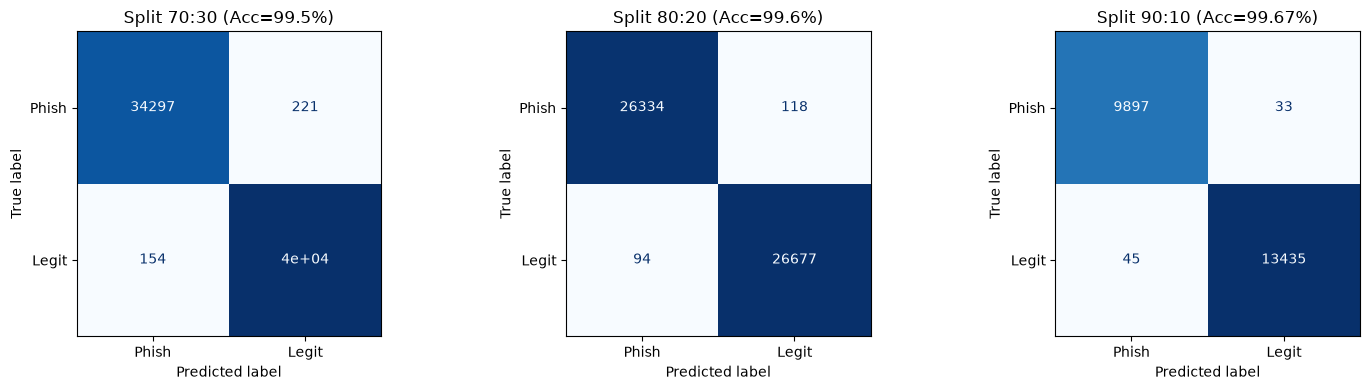

Perbandingan kinerja model FULL (URL + HTML) pada berbagai rasio split (fokus kelas phishing, label 0):
Rasio (latih:uji)  Jumlah Fitur  Accuracy (%)  Precision (%)  Recall (%)  F1-score (%)
            70:30            26         99.50          99.55       99.36         99.46
            80:20            27         99.60          99.64       99.55         99.60
            90:10            26         99.67          99.55       99.67         99.61


In [4]:
# JALANKAN UNTUK 3 RASIO + tampilkan confusion matrix & tabel perbandingan
RASIO = [(0.3, '70:30'), (0.2, '80:20'), (0.1, '90:10')]
hasil = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (ts, nm) in zip(axes, RASIO):
    print('=== Memproses rasio ' + nm + ' ===')
    r = pipeline_rasio(X, y, groups, ts, nm)
    hasil.append(r)
    judul = 'Split ' + nm + ' (Acc=' + str(round(r['acc']*100, 2)) + '%)'
    ConfusionMatrixDisplay(r['cm'], display_labels=['Phish', 'Legit']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(judul)
plt.tight_layout(); plt.show()

tabel = pd.DataFrame([{'Rasio (latih:uji)': h['rasio'], 'Jumlah Fitur': h['n_fitur'],
                       'Accuracy (%)': round(h['acc']*100, 2), 'Precision (%)': round(h['precision']*100, 2),
                       'Recall (%)': round(h['recall']*100, 2), 'F1-score (%)': round(h['f1']*100, 2)} for h in hasil])
print('Perbandingan kinerja model FULL (URL + HTML) pada berbagai rasio split (fokus kelas phishing, label 0):')
print(tabel.to_string(index=False))

=== Memproses rasio 80:20 ===


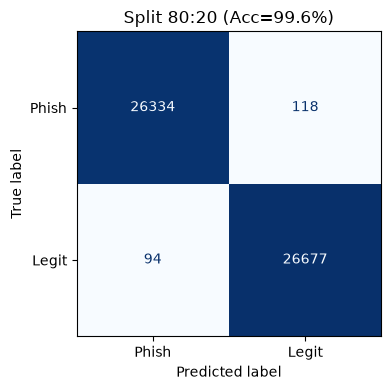

In [ ]:
# JALANKAN UNTUK RASIO 80:20 + tampilkan confusion matrix
print('=== Memproses rasio 80:20 ===')
r = pipeline_rasio(X, y, groups, 0.2, '80:20')

fig, ax = plt.subplots(figsize=(5, 4))
judul = 'Split 80:20 (Acc=' + str(round(r['acc']*100, 2)) + '%)'
ConfusionMatrixDisplay(r['cm'], display_labels=['Phishing', 'Legitimate']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(judul)
plt.tight_layout(); plt.show()